In [1]:
# ─── CELL 1: Installation ─────────────────────────────────────────────────────
import subprocess, sys

packages = [
    "qiskit>=1.0",
    "qiskit-ibm-runtime>=0.20",
    "qiskit-machine-learning>=0.7",
    "qiskit-aer>=0.14",
    "scikit-learn",
    "matplotlib",
    "numpy",
    "scipy",
    "tqdm",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ All packages installed successfully")


✅ All packages installed successfully


In [2]:
# ─── CELL 2: Imports ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# Standard
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import time
import json
from collections import defaultdict

# ML / Data
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)
import scipy.optimize as opt

# Qiskit core (≥ 1.x / 2.x)
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter, ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, PauliFeatureMap
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit.primitives import StatevectorSampler, StatevectorEstimator

# Qiskit Machine Learning (≥ 0.7)
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from qiskit_machine_learning.algorithms.classifiers import VQC, NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import COBYLA, SPSA

# IBM Quantum Runtime (≥ 0.20 for IBM Quantum 2.0)
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke  # noiseless-ish fake backend

print(f"✅ Qiskit         : {qiskit.__version__}")
import qiskit_machine_learning as qml_ver
print(f"✅ Qiskit-ML      : {qml_ver.__version__}")
import qiskit_ibm_runtime as qrt
print(f"✅ IBM Runtime    : {qrt.__version__}")

# Reproducibility
SEED = 42
np.random.seed(SEED)
print(f"✅ Random seed    : {SEED}")


✅ Qiskit         : 2.4.1
✅ Qiskit-ML      : 0.9.0
✅ IBM Runtime    : 0.47.0
✅ Random seed    : 42


In [3]:




# ─── CELL 3: Config ───────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — tweak these to match your setup / resources
# ─────────────────────────────────────────────────────────────────────────────

CFG = {
    # ── Data ────────────────────────────────────────────────────────────────
    "n_qubits"       : 4,       # number of qubits = PCA components = feature size
    "train_size"     : 200,     # training samples (keep small for quantum sim)
    "test_size"      : 60,      # test samples
    "classes"        : [0, 1],  # binary classification; change to any two digits

    # ── Circuit ─────────────────────────────────────────────────────────────
    "n_layers"       : 3,       # number of tunneling + variational layer pairs
    "reps_fm"        : 1,       # ZZFeatureMap repetitions
    "tunneling_init" : 0.5,     # initial κ value (uniform)

    # ── Training ────────────────────────────────────────────────────────────
    "optimizer"      : "SPSA",  # "COBYLA" | "SPSA" | "ADAM" | "SCIPY_L-BFGS-B"
    "max_iter"       : 150,     # max optimizer iterations
    "learning_rate"  : 0.01,    # for SPSA / gradient-based optimizers

    # ── Backend ─────────────────────────────────────────────────────────────
    # "simulator"  → local Qiskit Aer (fastest)
    # "fake_ibm"   → FakeSherbrooke noise model (IBM Quantum 2.0 compatible)
    # "real_ibm"   → real IBM hardware (requires IBM Quantum account + token)
    "backend_mode"   : "simulator",

    # ── IBM Quantum (only used when backend_mode == "real_ibm") ─────────────
    "ibm_token"      : "YOUR_IBM_QUANTUM_TOKEN_HERE",  # paste your token
    "ibm_channel"    : "ibm_quantum",
    "ibm_backend"    : "ibm_brisbane",  # or "ibm_kyoto", etc.

    # ── Misc ────────────────────────────────────────────────────────────────
    "shots"          : 1024,
    "seed"           : SEED,
}

print("Configuration:")
for k, v in CFG.items():
    print(f"  {k:<20} : {v}")


Configuration:
  n_qubits             : 4
  train_size           : 200
  test_size            : 60
  classes              : [0, 1]
  n_layers             : 3
  reps_fm              : 1
  tunneling_init       : 0.5
  optimizer            : SPSA
  max_iter             : 150
  learning_rate        : 0.01
  backend_mode         : simulator
  ibm_token            : YOUR_IBM_QUANTUM_TOKEN_HERE
  ibm_channel          : ibm_quantum
  ibm_backend          : ibm_brisbane
  shots                : 1024
  seed                 : 42


In [4]:

# ─── CELL 4: Data ─────────────────────────────────────────────────────────────
# ─── Load MNIST ───────────────────────────────────────────────────────────────
print("Loading MNIST …")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="liac-arff")
X_raw, y_raw = mnist.data, mnist.target.astype(int)

# ─── Filter to chosen binary classes ──────────────────────────────────────────
cls0, cls1 = CFG["classes"]
mask = (y_raw == cls0) | (y_raw == cls1)
X_raw, y_raw = X_raw[mask], y_raw[mask]
y_binary = (y_raw == cls1).astype(int)          # 0 → 0, cls1 → 1

print(f"  Class {cls0} samples : {(y_binary==0).sum()}")
print(f"  Class {cls1} samples : {(y_binary==1).sum()}")

# ─── Train / Test split ───────────────────────────────────────────────────────
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_raw, y_binary,
    train_size=CFG["train_size"],
    test_size=CFG["test_size"],
    stratify=y_binary,
    random_state=CFG["seed"],
)

# ─── PCA → n_qubits features ─────────────────────────────────────────────────
pca = PCA(n_components=CFG["n_qubits"], random_state=CFG["seed"])
X_tr_pca = pca.fit_transform(X_tr_raw)
X_te_pca = pca.transform(X_te_raw)

explained = pca.explained_variance_ratio_.sum() * 100
print(f"  PCA variance explained : {explained:.1f}%")

# ─── Normalize to [0, π] for angle encoding ───────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train = scaler.fit_transform(X_tr_pca)
X_test  = scaler.transform(X_te_pca)

print(f"  X_train shape : {X_train.shape}")
print(f"  X_test  shape : {X_test.shape}")
print("✅ Data ready")

Loading MNIST …
  Class 0 samples : 6903
  Class 1 samples : 7877
  PCA variance explained : 57.2%
  X_train shape : (200, 4)
  X_test  shape : (60, 4)
✅ Data ready


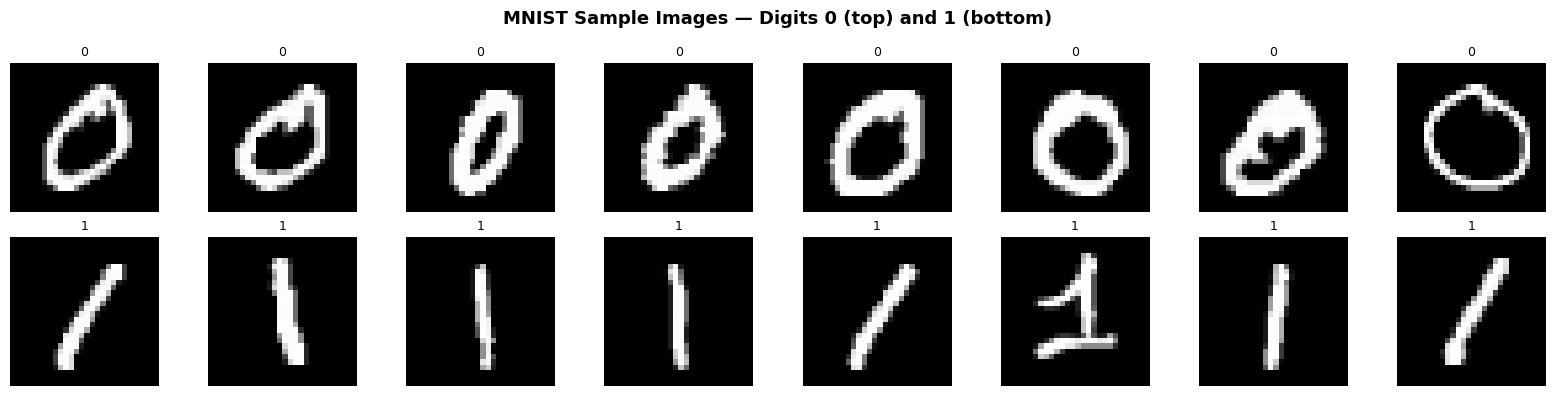

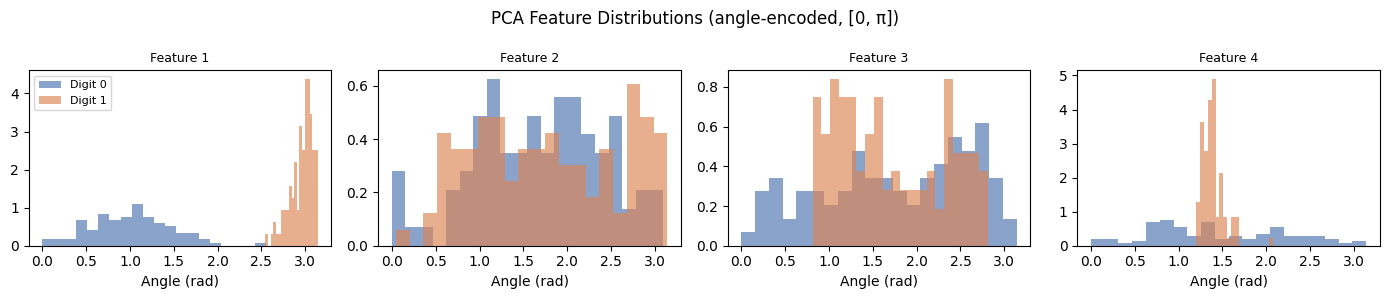

✅ Plots rendered


In [5]:


# ─── CELL 5: Visualize Data ───────────────────────────────────────────────────

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle(f"MNIST Sample Images — Digits {cls0} (top) and {cls1} (bottom)",
             fontsize=13, fontweight="bold")

for row, cls in enumerate(CFG["classes"]):
    idx = np.where(y_raw == cls)[0][:8]
    for col, i in enumerate(idx):
        axes[row, col].imshow(X_raw[i].reshape(28, 28), cmap="gray")
        axes[row, col].axis("off")
        axes[row, col].set_title(str(cls), fontsize=9)

plt.tight_layout()
plt.savefig("/tmp/mnist_samples.png", dpi=120, bbox_inches="tight")
plt.show()

# ─── PCA feature distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, CFG["n_qubits"], figsize=(14, 3))
fig.suptitle("PCA Feature Distributions (angle-encoded, [0, π])", fontsize=12)
colors = ["#4C72B0", "#DD8452"]

for i, ax in enumerate(axes):
    for j, cls in enumerate(CFG["classes"]):
        vals = X_train[y_train == j, i]
        ax.hist(vals, bins=20, alpha=0.65, color=colors[j],
                label=f"Digit {cls}", density=True)
    ax.set_title(f"Feature {i+1}", fontsize=9)
    ax.set_xlabel("Angle (rad)")
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/tmp/pca_features.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Plots rendered")



In [6]:
# ─── CELL 6: Quantum Circuit ──────────────────────────────────────────────────

### Theory
'''
For a 1-D quantum particle with energy $E$ hitting a rectangular barrier of height $V_0$ and width $d$:

$$\\kappa = \\frac{\\sqrt{2m(V_0-E)}}{\\hbar}, \\qquad T \\approx e^{-2\\kappa d}$$

We encode this physics into a parametric quantum circuit where every layer has a **learnable** $\\kappa$ vector:

| Gate | Role |
|------|------|
| `RY(xᵢ)` | Angle-encode input feature $x_i$ |
| `RZ(κᵢ)` | Per-qubit tunneling barrier height |
| `RZZ(κᵢⱼ)` | Inter-qubit tunneling coupling |
| `RY(θᵢ)` + `RZ(φᵢ)` | Variational rotations |
| `CX` | Entanglement ring |

**κ is adaptive**: its value differs per qubit and per layer, and is optimized end-to-end during training.
'''
def build_tunneling_circuit(n_qubits: int, n_layers: int) -> tuple:
    """
    Build the Adaptive Quantum Tunneling circuit.

    Returns
    -------
    qc          : full QuantumCircuit
    input_params: ParameterVector for feature encoding
    kappa_params: list of Parameter objects (the learnable tunneling coefficients)
    var_params  : list of Parameter objects (variational weights)
    """
    qc = QuantumCircuit(n_qubits, name="AQT-κ")

    # ── Parameter collections ─────────────────────────────────────────────────
    x      = ParameterVector("x", n_qubits)          # input features
    kappa  = []                                        # κ per layer
    theta  = []                                        # variational params

    # ─────────────────────────────────────────────────────────────────────────
    # 1.  ANGLE ENCODING
    #     Map classical feature xᵢ ∈ [0, π] onto qubit i via RY
    # ─────────────────────────────────────────────────────────────────────────
    qc.h(range(n_qubits))
    for i in range(n_qubits):
        qc.ry(x[i], i)
    qc.barrier(label="Encoding")

    # ─────────────────────────────────────────────────────────────────────────
    # 2.  TUNNELING + VARIATIONAL LAYERS
    # ─────────────────────────────────────────────────────────────────────────
    for layer in range(n_layers):

        # ── 2a. Tunneling barrier (κ per qubit) ──────────────────────────────
        k_layer = ParameterVector(f"κ_l{layer}", n_qubits + (n_qubits - 1))
        kappa.extend(list(k_layer))

        # Single-qubit tunneling: RZ(κᵢ)  — modulates barrier height
        for i in range(n_qubits):
            qc.rz(k_layer[i], i)

        # Two-qubit tunneling: RZZ(κᵢⱼ) — inter-qubit tunneling coupling
        for i in range(n_qubits - 1):
            qc.rzz(k_layer[n_qubits + i], i, i + 1)
        qc.barrier(label=f"κ L{layer}")

        # ── 2b. Variational layer (θ per qubit × 2) ───────────────────────────
        t_layer = ParameterVector(f"θ_l{layer}", 2 * n_qubits)
        theta.extend(list(t_layer))

        for i in range(n_qubits):
            qc.ry(t_layer[2 * i],     i)
            qc.rz(t_layer[2 * i + 1], i)

        # Entanglement ring (CNOT chain)
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
        qc.cx(n_qubits - 1, 0)          # close the ring
        qc.barrier(label=f"Var L{layer}")

    return qc, list(x), kappa, theta


# ── Build and inspect ─────────────────────────────────────────────────────────
n_q   = CFG["n_qubits"]
n_lay = CFG["n_layers"]

qc_aqt, x_params, kappa_params, var_params = build_tunneling_circuit(n_q, n_lay)

n_kappa = len(kappa_params)
n_var   = len(var_params)
n_total = n_kappa + n_var

print("=" * 60)
print("  Adaptive Quantum Tunneling Circuit — AQT-κ")
print("=" * 60)
print(f"  Qubits          : {n_q}")
print(f"  Layers          : {n_lay}")
print(f"  κ parameters    : {n_kappa}  (learnable tunneling coefficients)")
print(f"  Var parameters  : {n_var}  (variational weights)")
print(f"  Total params    : {n_total}")
print(f"  Depth           : {qc_aqt.depth()}")
print(f"  Gate count      : {dict(qc_aqt.count_ops())}")
print("=" * 60)


  Adaptive Quantum Tunneling Circuit — AQT-κ
  Qubits          : 4
  Layers          : 3
  κ parameters    : 21  (learnable tunneling coefficients)
  Var parameters  : 24  (variational weights)
  Total params    : 45
  Depth           : 32
  Gate count      : {'rz': 24, 'ry': 16, 'cx': 12, 'rzz': 9, 'barrier': 7, 'h': 4}


In [13]:
# ─── CELL 7: Draw circuit ─────────────────────────────────────────────────────
# Draw the full AQT-κ circuit
fig = qc_aqt.draw("mpl", fold=80, style="iqp",
                  plot_barriers=True, initial_state=False)
plt.suptitle("Adaptive Quantum Tunneling Circuit (AQT-κ)", y=1.01,
             fontsize=13, fontweight="bold")
plt.savefig("/tmp/aqt_circuit.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Circuit depth: {qc_aqt.depth()} | Gates: {qc_aqt.count_ops()}")

MissingOptionalLibraryError: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."

In [ ]:
!pip install pylatexenc

In [14]:
import importlib
try:
    import pylatexenc
    importlib.reload(pylatexenc)
    print("✅ pylatexenc detected and reloaded.")
    fig = qc_aqt.draw("mpl", fold=80, style="iqp", plot_barriers=True, initial_state=False)
    plt.suptitle("Adaptive Quantum Tunneling Circuit (AQT-κ)", y=1.01, fontsize=13, fontweight="bold")
    plt.show()
except ImportError:
    print("⚠️ pylatexenc still not found. Falling back to text-based drawer.")
    print(qc_aqt.draw("text"))

⚠️ pylatexenc still not found. Falling back to text-based drawer.
     ┌───┐┌──────────┐ Encoding ┌─────────────┐                            »
q_0: ┤ H ├┤ Ry(x[0]) ├────░─────┤ Rz(κ_l0[0]) ├─■──────────────────────────»
     ├───┤├──────────┤    ░     ├─────────────┤ │ZZ(κ_l0[4])               »
q_1: ┤ H ├┤ Ry(x[1]) ├────░─────┤ Rz(κ_l0[1]) ├─■─────────────■────────────»
     ├───┤├──────────┤    ░     ├─────────────┤               │ZZ(κ_l0[5]) »
q_2: ┤ H ├┤ Ry(x[2]) ├────░─────┤ Rz(κ_l0[2]) ├───────────────■────────────»
     ├───┤├──────────┤    ░     ├─────────────┤                            »
q_3: ┤ H ├┤ Ry(x[3]) ├────░─────┤ Rz(κ_l0[3]) ├────────────────────────────»
     └───┘└──────────┘    ░     └─────────────┘                            »
«                    κ L0 ┌─────────────┐┌─────────────┐               ┌───┐»
«q_0: ────────────────░───┤ Ry(θ_l0[0]) ├┤ Rz(θ_l0[1]) ├──■────────────┤ X ├»
«                     ░   ├─────────────┤├─────────────┤┌─┴─┐          └─┬─┘»
«q_1: ─

In [ ]:
!pip install qiskit[visualization]

In [17]:

# ─── CELL 8: Observable ──────────────────────────────────────────────────────

Z0 = SparsePauliOp("Z" + "I" * (n_q - 1))

print(f"Observable : {Z0}")

# ── Add measurements (for Sampler path; not needed for Estimator) ─────────────
qc_measured = qc_aqt.copy()
qc_measured.measure_all()

# ── EstimatorQNN wraps the AQT circuit ───────────────────────────────────────
estimator = StatevectorEstimator(seed=CFG["seed"])

qnn = EstimatorQNN(
    circuit        = qc_aqt,
    observables    = Z0,
    input_params   = x_params,
    weight_params  = kappa_params + var_params,  # κ and θ are BOTH trainable
    estimator      = estimator,
    input_gradients= False,
)

# Test forward pass with random weights
dummy_x = X_train[:3]                              # 3 samples
dummy_w = np.random.uniform(-np.pi, np.pi, n_total)
out = qnn.forward(dummy_x, dummy_w)

print(f"\\nQNN test forward pass:")
print(f"  Input  shape : {dummy_x.shape}")
print(f"  Output shape : {out.shape}")
print(f"  Raw outputs  : {out.ravel().round(4)}")
print("✅ EstimatorQNN configured successfully")

Observable : SparsePauliOp(['ZIII'],
              coeffs=[1.+0.j])
\nQNN test forward pass:
  Input  shape : (3, 4)
  Output shape : (3, 1)
  Raw outputs  : [-0.1881 -0.1187 -0.2611]
✅ EstimatorQNN configured successfully


In [18]:
# ─── CELL 9: Weight init ─────────────────────────────────────────────────────

def init_weights(n_kappa: int, n_var: int,
                 kappa_init: float = 0.5,
                 seed: int = 42) -> np.ndarray:
    """
    Initialise:
      κ (tunneling coefs) : small positive values near kappa_init
      θ (variational)     : Xavier-like uniform in [-π/2, π/2]
    """
    rng = np.random.default_rng(seed)

    # κ: small positive, centred on kappa_init with 10 % noise
    # Physical intuition: too-large κ → no tunneling; too-small → no barrier
    kappa_init_arr = (kappa_init
                      + 0.1 * rng.standard_normal(n_kappa))
    kappa_init_arr = np.clip(kappa_init_arr, 0.01, np.pi)

    # θ: Xavier-ish for rotational gates
    var_init_arr = rng.uniform(-np.pi / 2, np.pi / 2, n_var)

    return np.concatenate([kappa_init_arr, var_init_arr])


initial_weights = init_weights(n_kappa, n_var,
                                kappa_init=CFG["tunneling_init"],
                                seed=CFG["seed"])

print(f"Initial κ params (first 8) : {initial_weights[:8].round(3)}")
print(f"Initial θ params (first 8) : {initial_weights[n_kappa:n_kappa+8].round(3)}")
print(f"Total parameters           : {len(initial_weights)}")

Initial κ params (first 8) : [0.53  0.396 0.575 0.594 0.305 0.37  0.513 0.468]
Initial θ params (first 8) : [-0.457  1.479  1.235  0.875 -0.959 -0.105 -1.433 -1.086]
Total parameters           : 45


In [23]:
import time

# ─── CELL 10: Training (Fixed Callback) ──────────────────────────────────────

# ── Callback to record training curve ────────────────────────────────────────
train_log = {"iter": [], "loss": [], "kappa_mean": [], "kappa_std": []}
_iter_counter = [0]

def callback(*args):
    """
    Generalized callback to handle different optimizers.
    SPSA passes: (nfev, weights, loss, stepsize, accepted)
    COBYLA/Classifier passes: (weights, loss)
    """
    if len(args) == 5:
        _, weights, loss, _, _ = args
    else:
        weights, loss = args

    it = _iter_counter[0]
    _iter_counter[0] += 1

    # κ parameters are the first n_kappa weights
    k_vals = weights[:n_kappa]

    train_log["iter"].append(it)
    train_log["loss"].append(float(loss))
    train_log["kappa_mean"].append(float(k_vals.mean()))
    train_log["kappa_std"].append(float(k_vals.std()))

    if it % 10 == 0:
        print(f"  iter {it:>4d} | loss {loss:.4f} | κ̄ = {k_vals.mean():.3f} ± {k_vals.std():.3f}")

# ── Choose optimizer ─────────────────────────────────────────────────────────
if CFG["optimizer"] == "SPSA":
    optimizer = SPSA(maxiter=CFG["max_iter"],
                     learning_rate=CFG["learning_rate"],
                     perturbation=0.05)
else:
    optimizer = COBYLA(maxiter=CFG["max_iter"])

# ── Build classifier ─────────────────────────────────────────────────────────
classifier = NeuralNetworkClassifier(
    neural_network  = qnn,
    optimizer       = optimizer,
    loss            = "cross_entropy",
    initial_point   = initial_weights,
    callback        = callback,
)

# ── Train ─────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  Training AQT-κ Classifier")
print("=" * 60)
t0 = time.time()
classifier.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\n✅ Training complete in {elapsed:.1f}s")
print(f"   Total iterations : {_iter_counter[0]}")

  Training AQT-κ Classifier
  iter    0 | loss 17.4754 | κ̄ = 0.488 ± 0.202
  iter   10 | loss 4.8109 | κ̄ = 0.509 ± 0.673
  iter   20 | loss 1.1915 | κ̄ = 0.652 ± 1.265
  iter   30 | loss 0.6838 | κ̄ = 0.610 ± 1.243
  iter   40 | loss 0.6510 | κ̄ = 0.611 ± 1.238
  iter   50 | loss 0.5185 | κ̄ = 0.604 ± 1.246
  iter   60 | loss 0.4724 | κ̄ = 0.605 ± 1.252
  iter   70 | loss 0.4560 | κ̄ = 0.605 ± 1.257
  iter   80 | loss 0.4102 | κ̄ = 0.612 ± 1.259
  iter   90 | loss 0.4010 | κ̄ = 0.612 ± 1.256
  iter  100 | loss 0.3775 | κ̄ = 0.614 ± 1.259
  iter  110 | loss 0.3680 | κ̄ = 0.612 ± 1.259
  iter  120 | loss 0.3567 | κ̄ = 0.612 ± 1.263
  iter  130 | loss 0.3422 | κ̄ = 0.610 ± 1.261
  iter  140 | loss 0.3269 | κ̄ = 0.606 ± 1.260

✅ Training complete in 376.3s
   Total iterations : 150


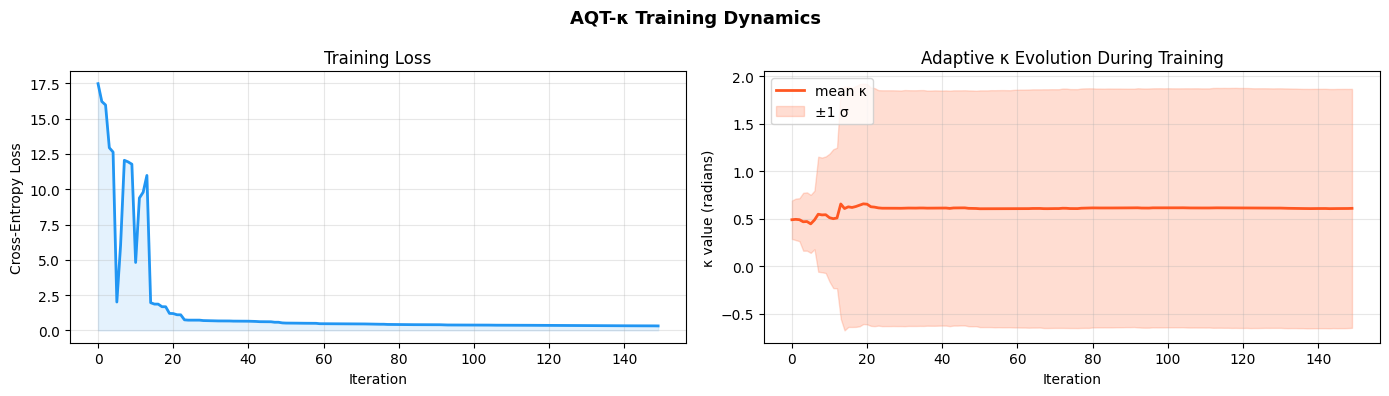

In [24]:
# ─── CELL 11: Training curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("AQT-κ Training Dynamics", fontsize=13, fontweight="bold")

# Loss curve
axes[0].plot(train_log["iter"], train_log["loss"], color="#2196F3", lw=2)
axes[0].fill_between(train_log["iter"], train_log["loss"],
                     alpha=0.12, color="#2196F3")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Training Loss")
axes[0].grid(alpha=0.3)

# κ evolution
axes[1].plot(train_log["iter"], train_log["kappa_mean"],
             color="#FF5722", lw=2, label="mean κ")
axes[1].fill_between(
    train_log["iter"],
    np.array(train_log["kappa_mean"]) - np.array(train_log["kappa_std"]),
    np.array(train_log["kappa_mean"]) + np.array(train_log["kappa_std"]),
    alpha=0.2, color="#FF5722", label="±1 σ",
)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("κ value (radians)")
axes[1].set_title("Adaptive κ Evolution During Training")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()


In [26]:
# ─── CELL 12: Evaluation (Fixed Labels) ──────────────────────────────────────

# Ensure predictions are mapped to [0, 1]
y_pred_train = classifier.predict(X_train).astype(int)
y_pred_test  = classifier.predict(X_test).astype(int)

# If QNN outputs -1/1, map them to 0/1
y_pred_train = np.where(y_pred_train == -1, 0, y_pred_train)
y_pred_test  = np.where(y_pred_test == -1, 0, y_pred_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

print("=" * 50)
print("  AQT-κ Classification Results")
print("=" * 50)
print(f"  Train accuracy : {acc_train:.4f} ({acc_train*100:.1f}%)")
print(f"  Test  accuracy : {acc_test:.4f}  ({acc_test*100:.1f}%)")
print()
print("Classification Report (Test):")
# Explicitly pass labels=[0, 1] to handle cases where one class might be missing in small sets
print(classification_report(y_test, y_pred_test,
                            labels=[0, 1],
                            target_names=[f"Digit {c}" for c in CFG["classes"]]))

  AQT-κ Classification Results
  Train accuracy : 0.7400 (74.0%)
  Test  accuracy : 0.7167  (71.7%)

Classification Report (Test):
              precision    recall  f1-score   support

     Digit 0       1.00      0.39      0.56        28
     Digit 1       0.65      1.00      0.79        32

    accuracy                           0.72        60
   macro avg       0.83      0.70      0.68        60
weighted avg       0.81      0.72      0.68        60



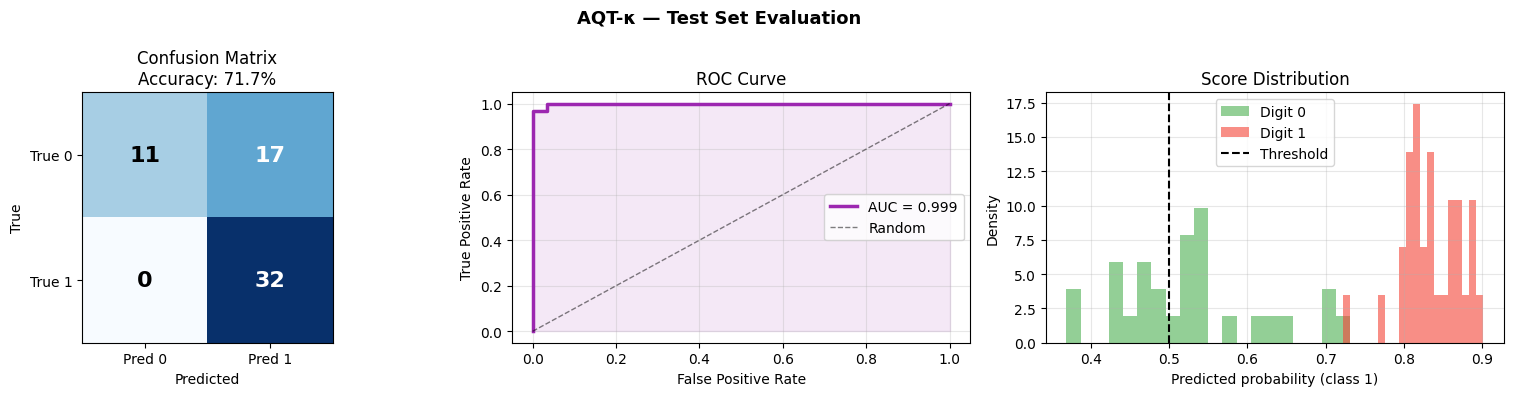

ROC-AUC: 0.9989


In [31]:
# ─── CELL 13: Confusion matrix ───────────────────────────────────────────────
# ── Raw QNN scores (before threshold) ────────────────────────────────────────
trained_w    = classifier.weights
raw_scores   = qnn.forward(X_test, trained_w).ravel()     # ∈ [-1, +1]
prob_class1  = (raw_scores + 1.0) / 2.0                    # map to [0, 1]

fpr, tpr, _ = roc_curve(y_test, prob_class1)
roc_auc      = auc(fpr, tpr)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("AQT-κ — Test Set Evaluation", fontsize=13, fontweight="bold")

# 1. Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
im = axes[0].imshow(cm, cmap="Blues")
for r in range(2):
    for c in range(2):
        axes[0].text(c, r, cm[r, c], ha="center", va="center",
                     fontsize=16, fontweight="bold",
                     color="white" if cm[r, c] > cm.max() / 2 else "black")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels([f"Pred {c}" for c in CFG["classes"]])
axes[0].set_yticklabels([f"True {c}" for c in CFG["classes"]])
axes[0].set_title(f"Confusion Matrix\nAccuracy: {acc_test*100:.1f}%")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# 2. ROC curve
axes[1].plot(fpr, tpr, color="#9C27B0", lw=2.5, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#9C27B0")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Score distribution
for j, cls in enumerate(CFG["classes"]):
    scores = prob_class1[y_test == j]
    axes[2].hist(scores, bins=20, alpha=0.6, density=True,
                 color=["#4CAF50", "#F44336"][j], label=f"Digit {cls}")
axes[2].axvline(0.5, color="k", lw=1.5, linestyle="--", label="Threshold")
axes[2].set_xlabel("Predicted probability (class 1)")
axes[2].set_ylabel("Density")
axes[2].set_title("Score Distribution")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/evaluation.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"ROC-AUC: {roc_auc:.4f}")

Learned κ values per layer:
--------------------------------------------------
  Layer 0:
    Single-qubit κᵢ : [ 1.928  0.701 -0.858  2.347]
    Coupling  κᵢℱ  : [0.058 2.694 0.906]
  Layer 1:
    Single-qubit κᵢ : [ 1.33  -1.079  0.786  0.36 ]
    Coupling  κᵢℱ  : [ 1.684 -0.993  1.528]
  Layer 2:
    Single-qubit κᵢ : [-0.628  2.107  0.722  0.394]
    Coupling  κᵢℱ  : [-0.016  1.182 -2.392]


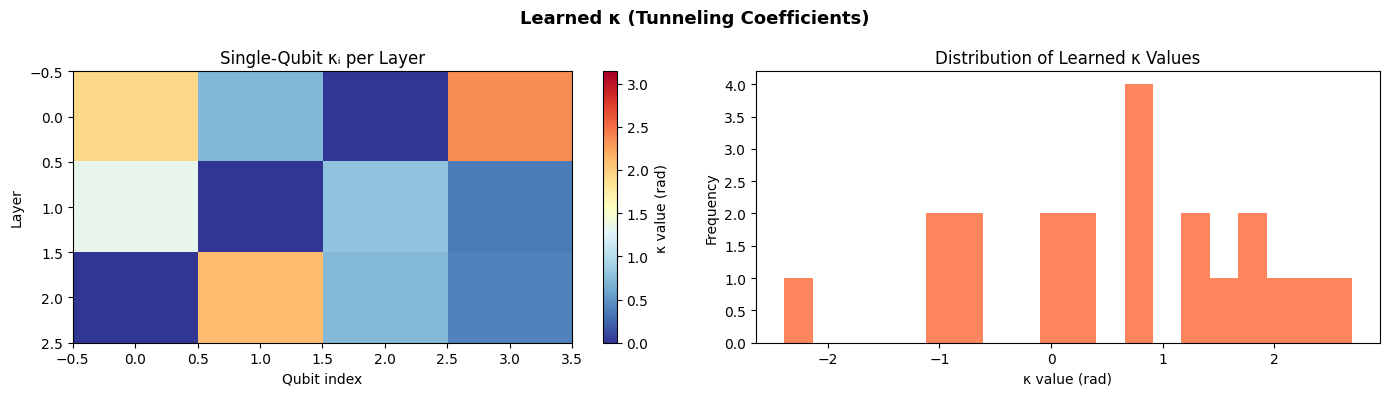

In [32]:
# ─── CELL 14: κ Analysis (Corrected Variable Access) ─────────────────────────
trained_w = classifier.weights
trained_kappa = trained_w[:n_kappa]
trained_theta = trained_w[n_kappa:]

n_kappa_per_layer = n_q + (n_q - 1)

print("Learned κ values per layer:")
print("-" * 50)
for layer in range(n_lay):
    start = layer * n_kappa_per_layer
    end   = start + n_kappa_per_layer
    k_l   = trained_kappa[start:end]
    qubit_k  = k_l[:n_q]
    couple_k = k_l[n_q:]
    print(f"  Layer {layer}:")
    print(f"    Single-qubit κᵢ : {qubit_k.round(3)}")
    print(f"    Coupling  κᵢℱ  : {couple_k.round(3)}")

# ── Heatmap of κ ──────────────────────────────────────────────
kappa_matrix = trained_kappa.reshape(n_lay, n_kappa_per_layer)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Learned κ (Tunneling Coefficients)", fontsize=13, fontweight="bold")

single_kappas = kappa_matrix[:, :n_q]
im = axes[0].imshow(single_kappas, cmap="RdYlBu_r", aspect="auto", vmin=0, vmax=np.pi)
plt.colorbar(im, ax=axes[0], label="κ value (rad)")
axes[0].set_xlabel("Qubit index")
axes[0].set_ylabel("Layer")
axes[0].set_title("Single-Qubit κᵢ per Layer")

axes[1].hist(trained_kappa, bins=20, color="#FF7043", alpha=0.85)
axes[1].set_xlabel("κ value (rad)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Learned κ Values")

plt.tight_layout()
plt.show()